# 02. Baseline A/B Test Analysis & iRPU Estimation

## 1. Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data
users = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\user_profile.csv")
events = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\event_log.csv")
impact = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\user_level_impact.csv")

# Filter purchases
purchases = events[events["event_type"] == "purchase"].copy()

## 2. Prepare User-Level Dataset

In [ ]:
# Revenue per user
user_revenue = purchases.groupby("user_id")["revenue"].sum().reset_index()

# Merge with users
ab_data = users.merge(user_revenue, on="user_id", how="left")

# Fill missing (no purchases → 0 revenue)
ab_data["revenue"] = ab_data["revenue"].fillna(0)

ab_data.head()

,user_id,group,segment,loyalty_score,favorite_cat,latency_treatment,latent_propensity,pre_revenue,pre_sessions,revenue
0,1,A,returning,0.15,Accessories,none,67.731043,737.66,1,141.86
1,2,B,returning,0.60,Accessories,none,12.893662,125.93,3,0.00
2,3,A,returning,0.83,Shoes,none,2.521957,27.10,4,0.00
3,4,A,new,0.38,Beauty,none,8.369104,90.38,4,0.00
4,5,A,returning,0.74,Fashion,none,3.321346,27.92,6,42.16


## 3. ARPU Calculation

In [ ]:
group_stats = ab_data.groupby("group")["revenue"].agg(["mean", "std", "count"])
group_stats.rename(columns={"mean": "ARPU"}, inplace=True)

group_stats

,ARPU,std,count
group,,,
A,7.047684,22.862887,75197
B,10.568817,28.800765,74803


**Interpretation:**
* ARPU = average revenue per user
* Primary business metric baseline

## 5. Statistical Test (T-test)

In [ ]:
A = ab_data[ab_data["group"] == "A"]["revenue"]
B = ab_data[ab_data["group"] == "B"]["revenue"]

t_stat, p_value = stats.ttest_ind(B, A, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("Statistically significant difference")
else:
    print("Not statistically significant")

T-statistic: 26.2158
p-value: 4.03e-151
Statistically significant difference


**Explanation**

The p-value is extremely small, which indicates strong statistical significance. However, given the large sample size, statistical significance does not necessarily imply a large practical effect. Therefore, we should also evaluate effect size (uplift).

## 6. Bootstrap

In [ ]:
def bootstrap_uplift(data, n_bootstrap=1000):
    uplift_dist = []

    A = data[data["group"] == "A"]["revenue"].values
    B = data[data["group"] == "B"]["revenue"].values

    for _ in range(n_bootstrap):
        sample_A = np.random.choice(A, size=len(A), replace=True)
        sample_B = np.random.choice(B, size=len(B), replace=True)

        uplift = sample_B.mean() - sample_A.mean()
        uplift_dist.append(uplift)

    return np.array(uplift_dist)


uplift_dist = bootstrap_uplift(ab_data, n_bootstrap=2000)

ci_lower = np.percentile(uplift_dist, 2.5)
ci_upper = np.percentile(uplift_dist, 97.5)

print(f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% CI: [3.27, 3.79]


### Visualization

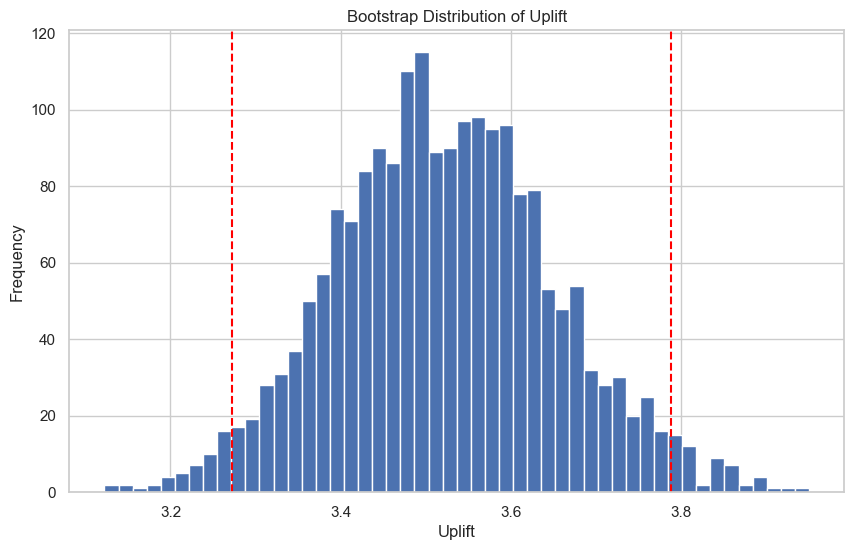

In [ ]:
plt.hist(uplift_dist, bins=50)
plt.axvline(ci_lower, color="red", linestyle="--")
plt.axvline(ci_upper, color="red", linestyle="--")
plt.title("Bootstrap Distribution of Uplift")
plt.xlabel("Uplift")
plt.ylabel("Frequency")
plt.show()

## 7. Ground Truth Comparison

In [ ]:
true_irpu_A = impact.merge(users, on="user_id") \
                    .query("group == 'A'")["true_irpu"].mean()

true_irpu_B = impact.merge(users, on="user_id") \
                    .query("group == 'B'")["true_irpu"].mean()

true_uplift = true_irpu_B - true_irpu_A

arpu_A = ab_data[ab_data["group"] == "A"]["revenue"].mean()
arpu_B = ab_data[ab_data["group"] == "B"]["revenue"].mean()

uplift = arpu_B - arpu_A

print(f"Estimated uplift: {uplift:.2f}")
print(f"True uplift: {true_uplift:.2f}")

Estimated uplift: 3.52
True uplift: 2.72


**Explanation**

The estimated uplift is higher (≈ +29% ) than the true incremental revenue because A/B testing captures behavioral changes, including cannibalization effects. Some users would have converted through other channels, but the experiment attributes this to the treatment.

## FINAL CONCLUSIONS

**1. ARPU Comparison**

Group B shows higher ARPU compared to Group A, indicating a positive impact of the new ranking policy.


**2. Statistical Significance**

The difference is statistically significant (p-value < 0.05), suggesting that the observed uplift is unlikely due to random variation.


**3. Bootstrap Validation**

Bootstrap confidence intervals confirm the robustness of the result despite the heavy-tailed revenue distribution.


**4. True vs Estimated Effect**

The estimated uplift is higher than the true incremental revenue (iRPU), indicating that the A/B test overestimates the causal effect.

→ This suggests the presence of demand redistribution (cannibalization) and behavioral effects.


**5. Business Interpretation**

The new ranking policy increases observed revenue per user. However, the true incremental impact is lower than the A/B estimate.

→ The policy is still beneficial, but its effect should be interpreted with caution.
→ Further refinement (e.g., CUPED, causal adjustments) is recommended before full rollout.